In [4]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

## 2. Calculer les rendements et performances

Le **rendement** mesure la variation relative du prix d’un actif entre deux périodes. C’est un indicateur clé de performance.

$$
R_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1
$$

Où :
* $(R_t)$ est le rendement à la date $(t)$
* $(P_t)$ est le prix de clôture à la date $(t)$
* $(P_{t-1})$ est le prix de clôture à la date précédente

#  Analyse Quantitative du Risque de Marché : Cas d'Étude NVIDIA

**Auteur :** ISLEYEN Volkan
**Contexte :** Master Finance de Marché / Portfolio Data Finance
**Sujet :** Modélisation et visualisation de la volatilité historique

---

## Description du Projet

Ce projet s'inscrit dans le cadre d'une analyse des risques financiers. L'objectif est d'étudier la **dynamique de la volatilité** de l'action NVIDIA (*NVDA*) sur une période charnière (2022-2024), marquée par l'essor de l'Intelligence Artificielle.

Plutôt que de se limiter à une analyse statique, ce module implémente une approche par **fenêtre glissante** (*Rolling Window*) pour capturer l'évolution temporelle du risque et les changements de régime de marché.

## Objectifs Techniques et Financiers

L'étude se décompose en quatre étapes clés :

1.  **Extraction de Données Financières :**
    * Récupération des séries temporelles OHLCV via l'API `yfinance`.
    * Période d'étude : **2022 - 2024**.
    * Actif sous-jacent : **NVIDIA Corp. (NVDA)**.

2.  **Traitement des Séries Temporelles :**
    * Calcul des rendements journaliers (Daily Returns).
    * Nettoyage et structuration des données avec `pandas`.

3.  **Modélisation de la Volatilité :**
    * Calcul de l'écart-type sur une **fenêtre glissante de 60 jours** pour lisser le bruit de marché à court terme.
    * **Annualisation de la volatilité** (facteur $\sqrt{252}$) pour obtenir une métrique standard comparables aux autres classes d'actifs.

4.  **Visualisation et Interprétation :**
    * Génération de graphiques dynamiques pour superposer l'évolution des cours et celle du risque.
    * Identification des périodes de stress (haute volatilité) vs périodes de consolidation.

## Stack Technique

* **Python 3.x**
* **Pandas** : Manipulation de séries temporelles financières.
* **Yfinance** : Récupération des données de marché.
* **Matplotlib / Seaborn** : Visualisation de données.
* **NumPy** : Calcul scientifique.

---
*Application pratique des méthodes d'analyse quantitative étudiées en Master Finance.*


In [5]:
import yfinance as yf
import pandas as pd

start = "2022-01-01"
end = "2024-12-31"
nvda = yf.download("NVDA", start = start, end = end)

[*********************100%***********************]  1 of 1 completed


In [ ]:
nvda.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2022-01-03,30.062761,30.651621,29.727411,29.757353,391547000
2022-01-04,29.233374,30.409096,28.294193,30.218465,527154000
2022-01-05,27.550634,29.359132,27.479772,28.893033,498064000
2022-01-06,28.123524,28.383021,27.012676,27.586564,454186000
2022-01-07,27.194321,28.367050,27.004687,28.086593,409939000


In [9]:
nvda.columns = nvda.columns.droplevel("Ticker")

## 2. Calculer les rendements et performances

Le **rendement** mesure la variation relative du prix d’un actif entre deux périodes. C’est un indicateur clé de performance.

$$
R_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1
$$

Où :
* $(R_t)$ est le rendement à la date $(t)$
* $(P_t)$ est le prix de clôture à la date $(t)$
* $(P_{t-1})$ est le prix de clôture à la date précédente

In [31]:
nvda["Return"] = nvda["Close"].pct_change()

In [32]:
nvda.head()

Price,Close,High,Low,Open,Volume,Rendement,Return,Volatility_60
Date,,,,,,,,
2022-01-03,30.062761,30.651621,29.727411,29.757353,391547000,NaN,NaN,NaN
2022-01-04,29.233374,30.409096,28.294193,30.218465,527154000,-0.027589,-0.027589,NaN
2022-01-05,27.550634,29.359132,27.479772,28.893033,498064000,-0.057562,-0.057562,NaN
2022-01-06,28.123524,28.383021,27.012676,27.586564,454186000,0.020794,0.020794,NaN
2022-01-07,27.194321,28.367050,27.004687,28.086593,409939000,-0.033040,-0.033040,NaN


In [33]:
nvda["Volatility_60"] = nvda["Return"].rolling(window=60).std()

In [34]:
nvda.tail()

Price,Close,High,Low,Open,Volume,Rendement,Return,Volatility_60
Date,,,,,,,,
2024-12-23,139.631805,139.751768,135.083047,136.242733,176053500,0.036897,0.036897,0.023751
2024-12-24,140.181671,141.861205,138.612093,139.961730,105157000,0.003938,0.003938,0.023750
2024-12-26,139.891739,140.811501,137.692343,139.661806,116205600,-0.002068,-0.002068,0.023195
2024-12-27,136.972534,138.981994,134.673175,138.512122,170582600,-0.020868,-0.020868,0.023341
2024-12-30,137.452393,140.231631,133.983341,134.793117,167734700,0.003503,0.003503,0.022984


In [37]:
nvda["Volatility_60"].describe()

count    692.000000
mean       0.034289
std        0.007107
min        0.018692
25%        0.029384
50%        0.036152
75%        0.039284
max        0.046458
Name: Volatility_60, dtype: float64

In [39]:
nvda["Volatility_60_annualised"] = nvda["Volatility_60"] * (252**0.5)

In [41]:
nvda.head()

Price,Close,High,Low,Open,Volume,Rendement,Return,Volatility_60,Volatility_60_annualised
Date,,,,,,,,,
2022-01-03,30.062761,30.651621,29.727411,29.757353,391547000,NaN,NaN,NaN,NaN
2022-01-04,29.233374,30.409096,28.294193,30.218465,527154000,-0.027589,-0.027589,NaN,NaN
2022-01-05,27.550634,29.359132,27.479772,28.893033,498064000,-0.057562,-0.057562,NaN,NaN
2022-01-06,28.123524,28.383021,27.012676,27.586564,454186000,0.020794,0.020794,NaN,NaN
2022-01-07,27.194321,28.367050,27.004687,28.086593,409939000,-0.033040,-0.033040,NaN,NaN


In [44]:
nvda["Volatility_60_annualised"].describe()

count    692.000000
mean       0.544322
std        0.112820
min        0.296726
25%        0.466452
50%        0.573896
75%        0.623614
max        0.737491
Name: Volatility_60_annualised, dtype: float64

In [43]:
nvda.tail()

Price,Close,High,Low,Open,Volume,Rendement,Return,Volatility_60,Volatility_60_annualised
Date,,,,,,,,,
2024-12-23,139.631805,139.751768,135.083047,136.242733,176053500,0.036897,0.036897,0.023751,0.377035
2024-12-24,140.181671,141.861205,138.612093,139.961730,105157000,0.003938,0.003938,0.023750,0.377014
2024-12-26,139.891739,140.811501,137.692343,139.661806,116205600,-0.002068,-0.002068,0.023195,0.368204
2024-12-27,136.972534,138.981994,134.673175,138.512122,170582600,-0.020868,-0.020868,0.023341,0.370527
2024-12-30,137.452393,140.231631,133.983341,134.793117,167734700,0.003503,0.003503,0.022984,0.364856


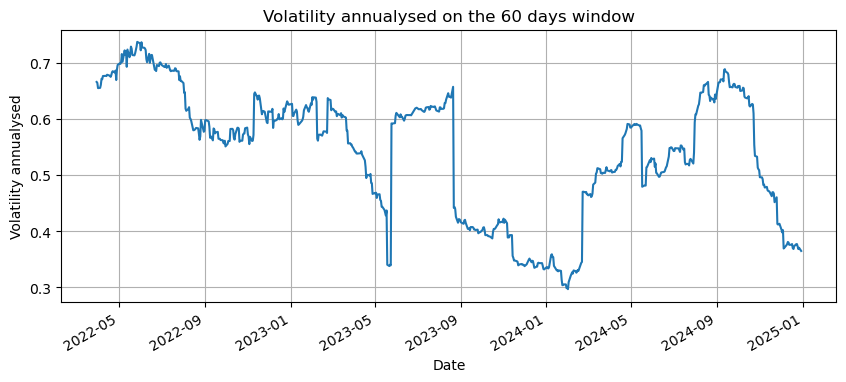

In [50]:
# Visualisation : 
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
nvda["Volatility_60_annualised"].plot(title="Volatility annualysed on the 60 days window")
plt.xlabel("Date")
plt.ylabel("Volatility annualysed")
plt.grid(True)
plt.show()